In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import PowerTransformer

warnings.filterwarnings('ignore')
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


In [2]:
# 读取数据
df = pd.read_excel(
    r'E:\pycharm all files\眼动数据处理\GSR\完整SCL处理分析\文件提取&GSR分解&去除异常值&绘图\GSR_SCL_AllEvents_cleanForPlot.xlsx')
df

FileNotFoundError: [Errno 2] No such file or directory: 'E:\\pycharm all files\\眼动数据处理\\GSR\\完整SCL处理分析\\文件提取&GSR分解&去除异常值&绘图\\GSR_SCL_AllEvents_pre1sBaseline_3sd'

In [3]:
# 读取数据
df = pd.read_excel(
    r'E:\pycharm all files\眼动数据处理\GSR\完整SCL处理分析\文件提取&GSR分解&去除异常值&绘图\GSR_SCL_AllEvents_pre1sBaseline_3sd.xlsx')
df

,orig_index,组别,姓名,飞行天数,阶段,data
0,0,A,付瑞晗,2,1,-1.094561e+05
1,1,A,付瑞晗,2,1,-1.095295e+05
2,2,A,付瑞晗,2,1,-1.096041e+05
3,3,A,付瑞晗,2,1,-1.096799e+05
4,4,A,付瑞晗,2,1,-1.097564e+05
...,...,...,...,...,...,...
399461,380385,A,黄博文,7,qifei,-2.959291e+06
399462,380386,A,黄博文,7,qifei,-2.959293e+06
399463,380387,A,黄博文,7,qifei,-2.959295e+06
399464,380388,A,黄博文,7,qifei,-2.959296e+06


In [4]:
len(df.姓名.unique())

32

In [5]:
# 查看缺失值
print('缺失值个数：', df.isnull().sum().sum())
# 查看异常值
df1 = df[df['data'].isnull()]
df1

缺失值个数： 0


,orig_index,组别,姓名,飞行天数,阶段,data


In [6]:
df = df.drop('orig_index', axis=1)
# 重置列名
df.columns = ['组别', '受试者', '飞行天数', '阶段', 'SCL']

# 将阶段为喝酒的行删掉
# df = df[df['阶段'] != 'hejiu']

# 重命名阶段
df['阶段'] = df['阶段'].replace(['1', '2', '3', '4'], '转弯')
df['阶段'] = df['阶段'].replace('qifei', '起飞')
df['阶段'] = df['阶段'].replace('jiangluo', '降落')
df['阶段'] = df['阶段'].replace('hejiu', '静息')

df

,组别,受试者,飞行天数,阶段,SCL
0,A,付瑞晗,2,转弯,-1.094561e+05
1,A,付瑞晗,2,转弯,-1.095295e+05
2,A,付瑞晗,2,转弯,-1.096041e+05
3,A,付瑞晗,2,转弯,-1.096799e+05
4,A,付瑞晗,2,转弯,-1.097564e+05
...,...,...,...,...,...
399461,A,黄博文,7,起飞,-2.959291e+06
399462,A,黄博文,7,起飞,-2.959293e+06
399463,A,黄博文,7,起飞,-2.959295e+06
399464,A,黄博文,7,起飞,-2.959296e+06


In [7]:
# 按阶段、组别、受试者、飞行天数分组，计算均值和中位数
df = df.groupby(['阶段', '组别', '受试者', '飞行天数'], as_index=False)['SCL'].agg(
    SCL均值='mean',
    SCL中位数='median'
)

df

# # 保存到新的 Excel 文件
# df.to_excel("GSR_SCL_阶段汇总数据.xlsx", index=False)
# 
# print("已生成文件：GSR_SCL_阶段汇总数据.xlsx")


,阶段,组别,受试者,飞行天数,SCL均值,SCL中位数
0,起飞,A,付瑞晗,2,6.578167e+05,6.576048e+05
1,起飞,A,付瑞晗,3,1.238580e+06,1.239496e+06
2,起飞,A,付瑞晗,4,6.835147e+05,6.864250e+05
3,起飞,A,付瑞晗,5,1.310422e+06,1.305388e+06
4,起飞,A,付瑞晗,6,2.006334e+06,1.983135e+06
...,...,...,...,...,...,...
762,静息,B,陈妍,3,5.928434e+05,5.946306e+05
763,静息,B,陈妍,4,1.005811e+06,1.005814e+06
764,静息,B,陈妍,5,2.102173e+09,2.587805e+07
765,静息,B,陈妍,6,7.993654e+05,7.993845e+05


In [8]:
# df_median使用ln(SCL)对数变换
df['SCL_median_ln'] = np.log(df['SCL中位数'])
df['SCL_mean_ln'] = np.log(df['SCL均值'])
df

,阶段,组别,受试者,飞行天数,SCL均值,SCL中位数,SCL_median_ln,SCL_mean_ln
0,起飞,A,付瑞晗,2,6.578167e+05,6.576048e+05,13.396359,13.396682
1,起飞,A,付瑞晗,3,1.238580e+06,1.239496e+06,14.030216,14.029476
2,起飞,A,付瑞晗,4,6.835147e+05,6.864250e+05,13.439252,13.435003
3,起飞,A,付瑞晗,5,1.310422e+06,1.305388e+06,14.082011,14.085860
4,起飞,A,付瑞晗,6,2.006334e+06,1.983135e+06,14.500189,14.511820
...,...,...,...,...,...,...,...,...
762,静息,B,陈妍,3,5.928434e+05,5.946306e+05,13.295696,13.292686
763,静息,B,陈妍,4,1.005811e+06,1.005814e+06,13.821307,13.821305
764,静息,B,陈妍,5,2.102173e+09,2.587805e+07,17.068906,21.466238
765,静息,B,陈妍,6,7.993654e+05,7.993845e+05,13.591597,13.591573


In [9]:
pt = PowerTransformer(method='yeo-johnson')
df[['SCL_median_yj', 'SCL_mean_yj']] = pt.fit_transform(df[['SCL中位数', 'SCL均值']])
df

,阶段,组别,受试者,飞行天数,SCL均值,SCL中位数,SCL_median_ln,SCL_mean_ln,SCL_median_yj,SCL_mean_yj
0,起飞,A,付瑞晗,2,6.578167e+05,6.576048e+05,13.396359,13.396682,0.156170,0.006613
1,起飞,A,付瑞晗,3,1.238580e+06,1.239496e+06,14.030216,14.029476,0.451005,0.008528
2,起飞,A,付瑞晗,4,6.835147e+05,6.864250e+05,13.439252,13.435003,0.169945,0.006697
3,起飞,A,付瑞晗,5,1.310422e+06,1.305388e+06,14.082011,14.085860,0.486247,0.008767
4,起飞,A,付瑞晗,6,2.006334e+06,1.983135e+06,14.500189,14.511820,0.865088,0.011106
...,...,...,...,...,...,...,...,...,...,...
762,静息,B,陈妍,3,5.928434e+05,5.946306e+05,13.295696,13.292686,0.126447,0.006402
763,静息,B,陈妍,4,1.005811e+06,1.005814e+06,13.821307,13.821305,0.328781,0.007756
764,静息,B,陈妍,5,2.102173e+09,2.587805e+07,17.068906,21.466238,19.896552,8.744940
765,静息,B,陈妍,6,7.993654e+05,7.993845e+05,13.591597,13.591573,0.224888,0.007076


In [10]:
# 替换组别名称
df["组别"] = df["组别"].replace({
    "A": "Alcohol",
    "B": "Control"
})
df

,阶段,组别,受试者,飞行天数,SCL均值,SCL中位数,SCL_median_ln,SCL_mean_ln,SCL_median_yj,SCL_mean_yj
0,起飞,Alcohol,付瑞晗,2,6.578167e+05,6.576048e+05,13.396359,13.396682,0.156170,0.006613
1,起飞,Alcohol,付瑞晗,3,1.238580e+06,1.239496e+06,14.030216,14.029476,0.451005,0.008528
2,起飞,Alcohol,付瑞晗,4,6.835147e+05,6.864250e+05,13.439252,13.435003,0.169945,0.006697
3,起飞,Alcohol,付瑞晗,5,1.310422e+06,1.305388e+06,14.082011,14.085860,0.486247,0.008767
4,起飞,Alcohol,付瑞晗,6,2.006334e+06,1.983135e+06,14.500189,14.511820,0.865088,0.011106
...,...,...,...,...,...,...,...,...,...,...
762,静息,Control,陈妍,3,5.928434e+05,5.946306e+05,13.295696,13.292686,0.126447,0.006402
763,静息,Control,陈妍,4,1.005811e+06,1.005814e+06,13.821307,13.821305,0.328781,0.007756
764,静息,Control,陈妍,5,2.102173e+09,2.587805e+07,17.068906,21.466238,19.896552,8.744940
765,静息,Control,陈妍,6,7.993654e+05,7.993845e+05,13.591597,13.591573,0.224888,0.007076


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['SCL_median_yj_z'] = scaler.fit_transform(df[['SCL_median_yj']])
df['SCL_mean_yj_z'] = scaler.fit_transform(df[['SCL_mean_yj']])

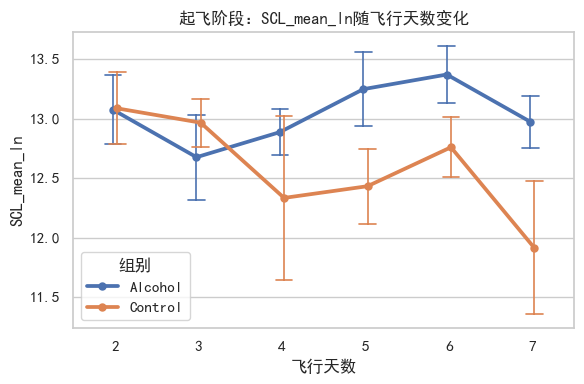

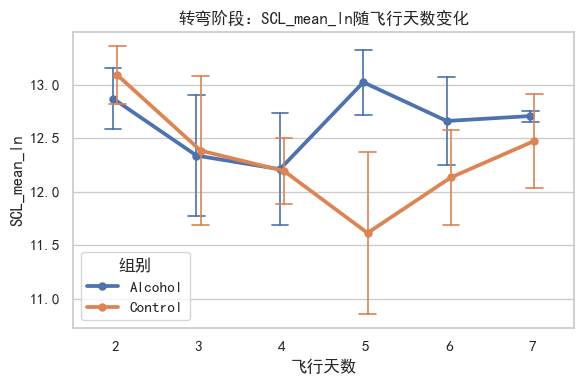

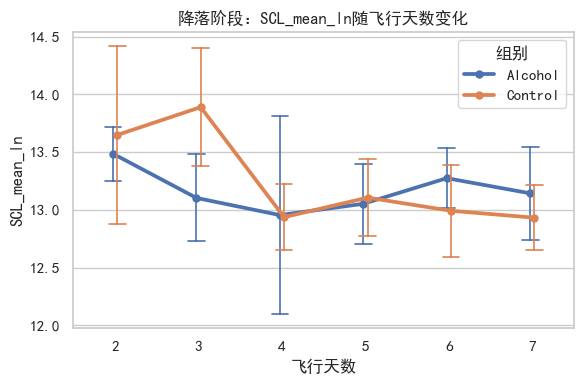

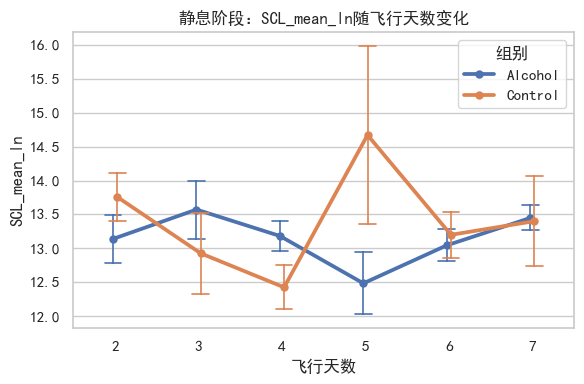

In [14]:
# 设定绘图风格
sns.set(style="whitegrid", font="SimHei")  # 支持中文显示

# 三个阶段
phases = df["阶段"].unique()
label = 'SCL_mean_ln'
# 建立图表
for phase in phases:
    plt.figure(figsize=(6, 4))

    # if phase != "降落":
    #     continue
    # 筛选该阶段数据
    sub_df = df[df["阶段"] == phase]

    sns.pointplot(
        data=sub_df,
        x="飞行天数",
        y=label,
        hue="组别",
        # errorbar=("ci", 95), # 误差线显示 95% 置信区间 # 或 ("se", 1)
        errorbar=("se", 1),  # 画标准误 误差线显示 ±1 标准误
        dodge=True,
        join=True,
        capsize=0.2,  # 控制小横线长度 (相对比例)
        errwidth=1.2,  # 误差线粗细，可调
        markersize=4
    )

    plt.title(f"{phase}阶段：{label}随飞行天数变化")
    plt.xlabel("飞行天数")
    plt.ylabel(label)
    # plt.ylim(12.5, 15)
    # plt.ylim(13, 18)
    plt.legend(title="组别")
    plt.tight_layout()
    plt.show()


In [17]:
df[(df['阶段'] == '降落')]

,阶段,组别,受试者,飞行天数,SCL均值,SCL中位数,SCL_median_ln,SCL_mean_ln,SCL_median_yj,SCL_mean_yj
384,降落,Alcohol,付瑞晗,2,1.334699e+06,1.335060e+06,14.104487,14.104217,0.717426,0.003043
385,降落,Alcohol,付瑞晗,3,1.433130e+06,1.438420e+06,14.179056,14.175371,0.864596,0.005386
386,降落,Alcohol,付瑞晗,4,1.285809e+06,1.284242e+06,14.065679,14.066899,0.643372,0.001865
387,降落,Alcohol,付瑞晗,5,1.881739e+06,1.880646e+06,14.447126,14.447707,1.450804,0.015647
388,降落,Alcohol,付瑞晗,6,1.644461e+06,1.644344e+06,14.312852,14.312923,1.145536,0.010298
...,...,...,...,...,...,...,...,...,...,...
570,降落,Control,陈妍,3,5.926664e+05,5.926925e+05,13.292431,13.292387,-0.526592,-0.016256
571,降落,Control,陈妍,4,8.148878e+05,8.151237e+05,13.611095,13.610806,-0.108283,-0.010090
572,降落,Control,陈妍,5,1.147268e+06,1.146911e+06,13.952582,13.952894,0.437026,-0.001530
573,降落,Control,陈妍,6,8.406935e+05,8.417503e+05,13.643239,13.641982,-0.061532,-0.009400


In [12]:
# df4 = df[(df['阶段'] == '降落') & (df['受试者'] == '周鑫颜') & (df['飞行天数'] == 2)]
# #去掉df中的df4
# df = df[df.index.isin(df4.index) == False]
# df
# # 输出